In [ ]:
#读取pdb_list.txt中的每一行，用“/“分割，取第6个元素为结构域名称，第7个元素为pdb名称，如果有第八个元素，则将第七个元素和第八个元素用-组合成新的pdb名称
with open('pdb_list.txt', 'r') as file:
    for line in file:
        parts = line.strip().split('/')
        domain_name = parts[6]
        pdb_name = parts[7]
        if len(parts) > 9:
            pdb_name = f"{pdb_name}-{parts[8]}-{parts[9]}"
        elif len(parts) > 8:
            pdb_name = f"{pdb_name}-{parts[8]}"
        print(f"Domain: {domain_name}, PDB: {pdb_name}")


        
        output_path = f"./outputs/{domain_name}/{pdb_name}"

In [ ]:
# 读取pdb_list.txt中的每一行对应路径的pdb文件，分别记录A链和B链的残基数目，统计残基数目少的链的个数

with open('pdb_list.txt', 'r') as file:
    short_chain_count = 0
    for line in file:
        pdb_path = line.strip()
        with open(pdb_path, 'r') as pdb_file:
            chain_a_residues = set()
            chain_b_residues = set()
            for pdb_line in pdb_file:
                if pdb_line.startswith("ATOM"):
                    chain_id = pdb_line[21]
                    residue_number = pdb_line[22:26].strip()
                    if chain_id == 'A':
                        chain_a_residues.add(residue_number)
                    elif chain_id == 'B':
                        chain_b_residues.add(residue_number)
            if len(chain_a_residues) < len(chain_b_residues):
                short_chain_count += 1
    print(f"Number of structures where chain A has fewer residues than chain B: {short_chain_count}")

#### 统计不同方法下的seq rec

### 26.02.05: 忽略PepSet中超过两条链的结果

In [4]:
# 读取“/home/junjiechen/1_work/250401-Dpepalign/MDM2-p53/v2.1_PDB/2_benchmark/21_ProteinMPNN”目录下所有的.fa文件，将所有的“seq_rec="后面的数字提取出来，计算这些数字的平均值
import os
import re
import pandas as pd

dataset = "PepSet"
noise_set = ["", "-noise-0.1", "-noise-0.2", "-noise-0.3", "-noise-0.4", "-noise-0.5"]



for noise in noise_set:
    out_dir = f"./outputs/{dataset}{noise}"

    with open(f'./datasets/{dataset}-PDB.list', 'r') as f:
        pdbs = [line.strip() for line in f.readlines()]

    id = out_dir.split("-")[-1].split(".")[-1] if noise != "" else "0"

    print(f"Processing seq_rec values in directory: {out_dir}")

    methods = ["LigandMPNN", "LigandMPNN-HETATM", "Rosetta", "Rosetta_betajan25_cart"]
    res = {"LigandMPNN": [5, 10, 20, 30], "LigandMPNN-HETATM": [5, 10, 20, 30], "ProteinMPNN": [2, 10, 20, 30], "Rosetta": ["ref2015"], "Rosetta_betajan25_cart": ["betajan25_cart"]}
    seq_rec_values = {f'{method}-{res[method][i]}': [] for method in methods for i in range(len(res[method]))}
    for method in methods:
        if method == "ProteinMPNN" or method == "LigandMPNN" or method == "LigandMPNN-HETATM":
            for i in range(len(res[method])):
                fa_dir = f"{out_dir}/{method}/{res[method][i]}"
                for root, dirs, files in os.walk(fa_dir):
                    for file in files:
                        if file.endswith(".fa") and file.split('.')[0] in pdbs:
                            fa_path = os.path.join(root, file)
                            with open(fa_path, 'r') as fa_file:
                                for line in fa_file:
                                    match = re.search(r'seq_rec=(\d+\.\d+)', line)
                                    if match:
                                        seq_rec_values[f'{method}-{res[method][i]}'].append(round(float(match.group(1)) * 100, 2))
        elif method == "Rosetta" or method == "Rosetta_betajan25_cart":
            for i in range(len(res[method])):
                fa_dir = f"{out_dir}/{method}"
                for root, dirs, files in os.walk(fa_dir):
                    for file in files:
                        dir = root.split('/')[-1]
                        if dir in pdbs:
                            if file.endswith(".sc"):
                                fa_path = os.path.join(root, file)
                                try:
                                    df = pd.read_csv(fa_path, sep=r'\s+', skiprows=1) # type: ignore
                                except pd.errors.ParserError as e:
                                    print(f"Error parsing file {fa_path}: {e}")
                                    continue
                                if 'seqrec_L' in df.columns:
                                    seq_rec_values[f"{method}-{res[method][i]}"].extend(round(df['seqrec_L'].astype(float) * 100, 2).tolist())
                                else:
                                    print(f"'seqrec_L' column not found in file {fa_path}")
    for key in seq_rec_values:
        if seq_rec_values[key]:
            average_seq_rec = sum(seq_rec_values[key]) / len(seq_rec_values[key])
            print(f"method: {key}, seqs_num: {len(seq_rec_values[key])}, Average seq_rec value: {average_seq_rec}")
        else:
            print("No seq_rec values found.")

    # 将seq_rec_values保存为pd.DataFrame，并保存为csv文件，行索引为pdb名称
    df_seq_rec = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in seq_rec_values.items()]))
    df_seq_rec.to_csv(f"{out_dir}/seq_rec_values-{id}-dimer.csv", index=False)

Processing seq_rec values in directory: ./outputs/PepSet
method: LigandMPNN-5, seqs_num: 1700, Average seq_rec value: 44.97147058823529
method: LigandMPNN-10, seqs_num: 1700, Average seq_rec value: 45.011370588235295
method: LigandMPNN-20, seqs_num: 1700, Average seq_rec value: 43.92381176470588
method: LigandMPNN-30, seqs_num: 1700, Average seq_rec value: 40.98654117647059
method: LigandMPNN-HETATM-5, seqs_num: 1700, Average seq_rec value: 36.435317647058824
method: LigandMPNN-HETATM-10, seqs_num: 1700, Average seq_rec value: 30.89938823529412
method: LigandMPNN-HETATM-20, seqs_num: 1700, Average seq_rec value: 32.36143529411765
method: LigandMPNN-HETATM-30, seqs_num: 1700, Average seq_rec value: 29.684941176470588
method: Rosetta-ref2015, seqs_num: 1700, Average seq_rec value: 38.13341176470588
method: Rosetta_betajan25_cart-betajan25_cart, seqs_num: 1700, Average seq_rec value: 33.841352941176474
Processing seq_rec values in directory: ./outputs/PepSet-noise-0.1
method: LigandMPNN-5

In [6]:
## test
dirs = [dir for dir in os.listdir("/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_weight/outputs/PepSet/Rosetta") if (not dir.endswith(".csv"))]
with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_weight/datasets/PepSet/PDB.list', 'r') as f:
    pdbs = [line.strip().split('/')[-1].split('.')[0] for line in f.readlines()]
sc_count = 0
for dir in dirs:
    # 如果目录下没有以pdb结尾的文件，打印该目录
    if not any(f.endswith('.pdb') for f in os.listdir(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_weight/outputs/PepSet/Rosetta/{dir}')):
        print(f'Directory {dir} does not contain any .pdb files.')
    # 检查
    # 统计sc文件个数
    sc_count += sum(1 for f in os.listdir(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_weight/outputs/PepSet/Rosetta/{dir}') if f.endswith('.sc'))
print(f'Contains {sc_count} .sc files.')

Contains 181 .sc files.


In [10]:
with open('/home/junjiechen/1_work/250401-Dpepalign/Benchmark/ligandmpnn/test_weight/datasets/PepSet/PDB.list', 'r') as f:
    pdbs = [line.strip().split('/')[-1].split('.')[0] for line in f.readlines()]
diff = set(pdbs) - set(dirs)

print(f"Directories in PDB.list but not in outputs: {diff}")


Directories in PDB.list but not in outputs: {'6h7b'}


In [2]:
# 只提取method为LigandMPNN、LigandMPNN-HETATM、ProteinMPNN和Rosetta的结果，保存到filter_seq_rec_value字典中
filter_key = ["LigandMPNN-5", "LigandMPNN-10", "LigandMPNN-20", "LigandMPNN-30", "LigandMPNN-HETATM-5", "LigandMPNN-HETATM-10", "LigandMPNN-HETATM-20", "LigandMPNN-HETATM-30", "ProteinMPNN-2", "ProteinMPNN-10", "ProteinMPNN-20", "ProteinMPNN-30", "Rosetta-ref2015"]
filter_seq_rec_values = {key: seq_rec_values[key] for key in filter_key if key in seq_rec_values}
for key in filter_seq_rec_values:
    if filter_seq_rec_values[key]:
        average_seq_rec = sum(filter_seq_rec_values[key]) / len(filter_seq_rec_values[key])
        median_seq_rec = sorted(filter_seq_rec_values[key])[len(filter_seq_rec_values[key]) // 2]
        print(f"method: {key}, seqs_num: {len(filter_seq_rec_values[key])}, Average seq_rec value: {average_seq_rec}, Median seq_rec value: {median_seq_rec}")
    else:
        print("No seq_rec values found.")

method: LigandMPNN-5, seqs_num: 1810, Average seq_rec value: 41.10227071823204, Median seq_rec value: 40.0
method: LigandMPNN-10, seqs_num: 1810, Average seq_rec value: 42.4351546961326, Median seq_rec value: 42.86
method: LigandMPNN-20, seqs_num: 1810, Average seq_rec value: 43.34095027624309, Median seq_rec value: 42.86
method: LigandMPNN-30, seqs_num: 1810, Average seq_rec value: 40.63190607734806, Median seq_rec value: 40.0
method: LigandMPNN-HETATM-5, seqs_num: 1810, Average seq_rec value: 32.7852044198895, Median seq_rec value: 33.33
method: LigandMPNN-HETATM-10, seqs_num: 1810, Average seq_rec value: 29.738823204419887, Median seq_rec value: 28.57
method: LigandMPNN-HETATM-20, seqs_num: 1810, Average seq_rec value: 30.560044198895028, Median seq_rec value: 30.0
method: LigandMPNN-HETATM-30, seqs_num: 1810, Average seq_rec value: 28.50925414364641, Median seq_rec value: 27.27
method: ProteinMPNN-2, seqs_num: 1810, Average seq_rec value: 36.63664640883978, Median seq_rec value: 37

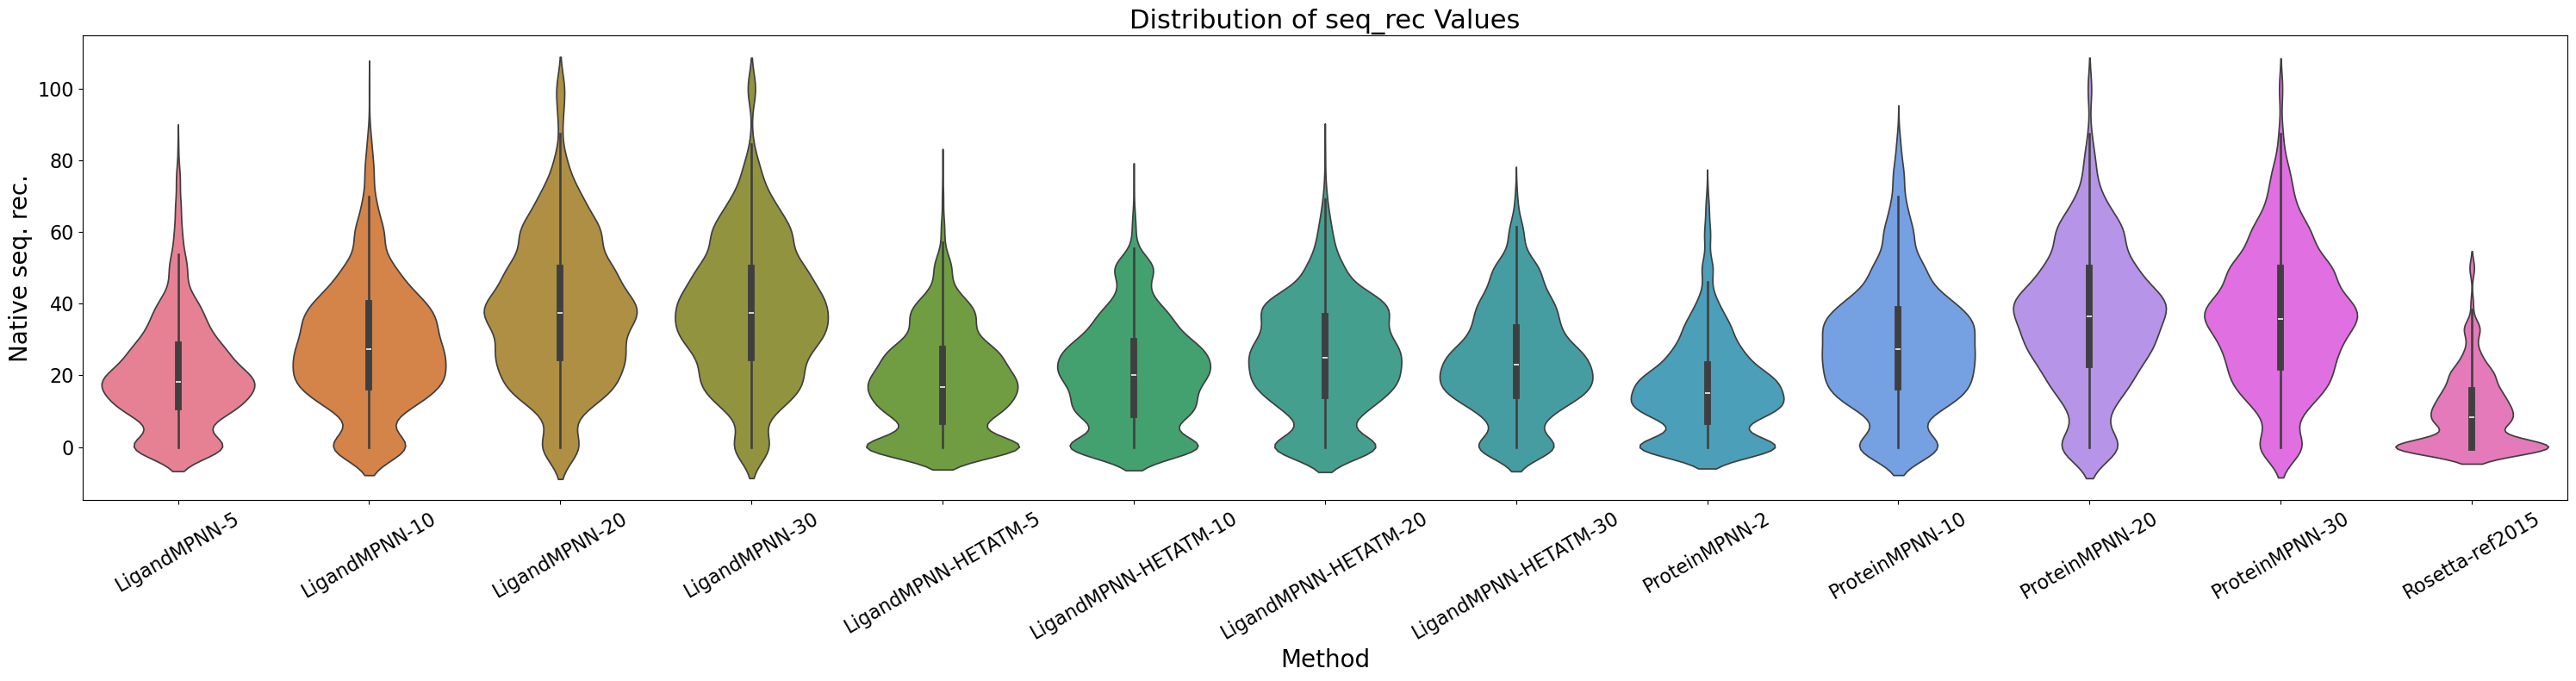

In [7]:
# 将seq_rec_values绘制成小提琴图
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30, 8))
sns.violinplot(data=filter_seq_rec_values, inner="box")
plt.title("Distribution of seq_rec Values", fontsize=22)
plt.xlabel("Method", fontsize=20)
plt.ylabel("Native seq. rec.", fontsize=20)
plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
# plt.savefig("seq_rec-violin_plot-correct.png")
plt.show()

In [ ]:
import os

dir1 = "/home/junjiechen/1_work/250401-Dpepalign/MDM2-p53/v2.1_PDB/2_benchmark/Rosetta/2_Rosetta"
dir2 = "/home/junjiechen/1_work/250401-Dpepalign/MDM2-p53/v2.1_PDB/2_benchmark/Rosetta/3_Rosetta"

# 统计哪些文件在dir1中有但在dir2中没有
missing_in_dir2 = []
for root, dirs, files in os.walk(dir1):
    for name in dirs + files:
        path1 = os.path.join(root, name)
        relative_path = os.path.relpath(path1, dir1)
        path2 = os.path.join(dir2, relative_path)
        if not os.path.exists(path2):
            missing_in_dir2.append(relative_path)
print("Files and directories present in dir1 but missing in dir2:")
for item in missing_in_dir2:
    print(item)
